# 02 — Loan Amount Prediction

Evaluate the serialized production loan-amount model on the same feature engineering pipeline used by the API. The notebook never writes a model file.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)

Project root: c:\Users\Dinesh more\OneDrive\Desktop\bank-loan-credit-risk-analysis\bank-loan-credit-risk-analysis


In [2]:
import json
import joblib
import pandas as pd
import numpy as np

from src.pipeline_utils import clean_common, feature_frame, CONFIG

models = {
    'loan_amount': joblib.load(ROOT/'models/loan_amount.joblib'),
    'loan_approval': joblib.load(ROOT/'models/loan_approval.joblib'),
    'credit_score': joblib.load(ROOT/'models/credit_score.joblib'),
    'credit_risk': joblib.load(ROOT/'models/credit_risk.joblib'),
}
print('Loaded:', ', '.join(models))

c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead 

Loaded: loan_amount, loan_approval, credit_score, credit_risk


c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

loan = clean_common(pd.read_csv(ROOT/'data/raw/loan_data.csv'))
approved = loan[loan.loan_status.eq('Approved')].copy()
X = feature_frame(approved, CONFIG['features']['loan_amount'])
y = approved['approved_loan_amount'].clip(upper=approved['requested_loan_amount'])
_, X_test, _, y_test = train_test_split(X, y, test_size=.20, random_state=42)
pred = models['loan_amount'].predict(X_test)
pred = np.clip(pred, 0, approved.loc[X_test.index,'requested_loan_amount'])
print('MAE:', mean_absolute_error(y_test,pred))
print('RMSE:', mean_squared_error(y_test,pred)**0.5)
print('R2:', r2_score(y_test,pred))

MAE: 30814.57946354833
RMSE: 47756.22540987955
R2: 0.9485321797140178


In [4]:
comparison = pd.DataFrame({'actual':y_test, 'predicted':pred})
comparison['absolute_error']=(comparison.actual-comparison.predicted).abs()
display(comparison.head(20))

,actual,predicted,absolute_error
4166,163700.0,1.369133e+05,26786.667460
7367,287000.0,3.217554e+05,34755.355088
6658,402000.0,3.532359e+05,48764.098771
11810,347600.0,3.113846e+05,36215.391327
964,182700.0,1.619075e+05,20792.508862
773,137200.0,1.329994e+05,4200.640938
7282,909600.0,1.054144e+06,144544.102441
1928,399300.0,3.734321e+05,25867.920382
11270,382100.0,3.985398e+05,16439.773489
10682,159000.0,1.719086e+05,12908.590188


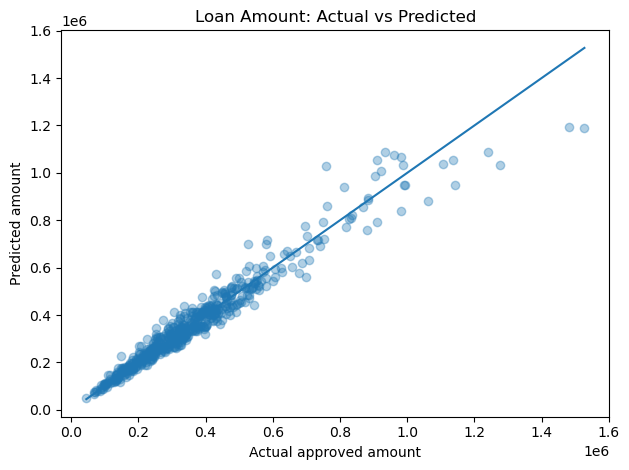

In [5]:
import matplotlib.pyplot as plt
plt.scatter(y_test, pred, alpha=.35)
lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max())
plt.plot([lo,hi],[lo,hi])
plt.xlabel('Actual approved amount'); plt.ylabel('Predicted amount'); plt.title('Loan Amount: Actual vs Predicted'); plt.tight_layout(); plt.show()

## Production contract
The API caps the final approved amount to the requested amount. Keep this business rule when using the model outside the notebook.